### f) Effect of the recycle ratio on dilution rate, cell concentrations and productivity 

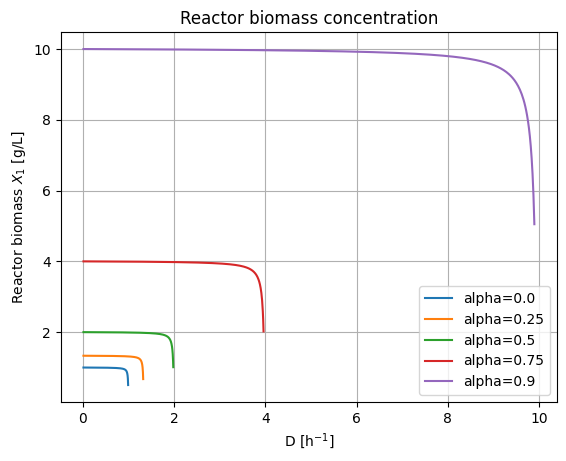

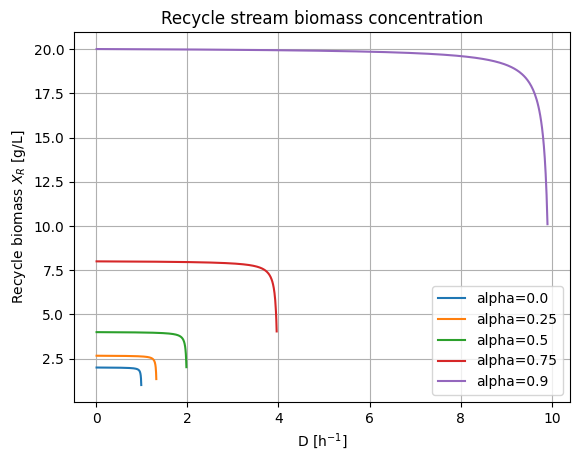

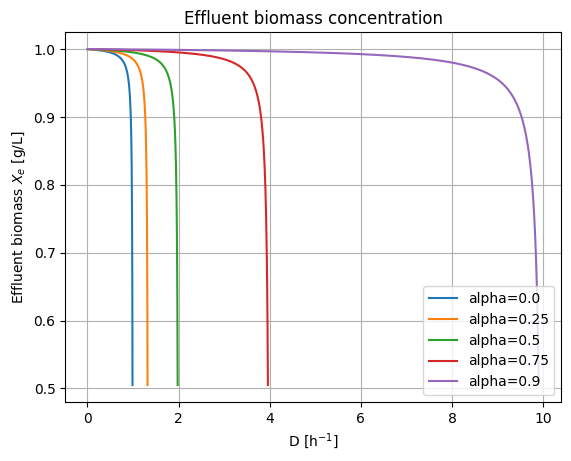

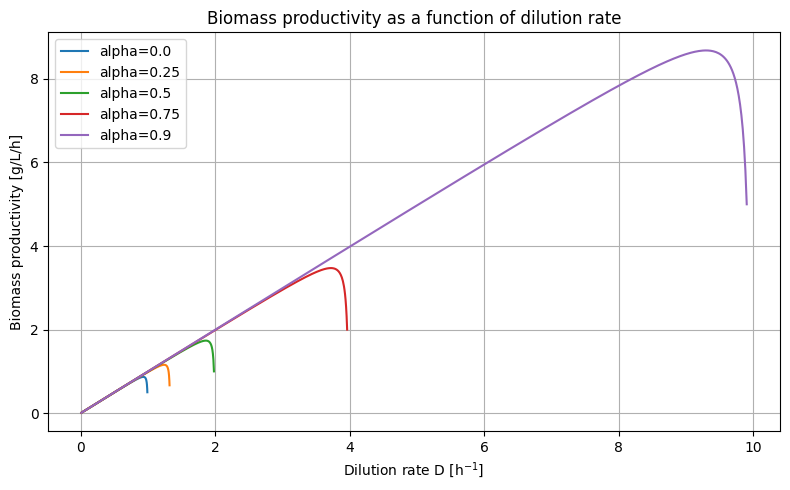

Maximum dilution rates:
alpha = 0.00 --> Dmax = 1.000 h^-1
alpha = 0.25 --> Dmax = 1.333 h^-1
alpha = 0.50 --> Dmax = 2.000 h^-1
alpha = 0.75 --> Dmax = 4.000 h^-1
alpha = 0.90 --> Dmax = 10.000 h^-1


In [3]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
Yxs = 0.5       # gDW cells / g substrate
S0 = 2.0        # g/L
mumax = 1.0     # 1/h
Ks = 0.01       # g/L
C = 2.0         # concentration factor

alpha_values = [0.0, 0.25, 0.5, 0.75, 0.9]

# Functions
def mu_from_D(D, alpha, C):
    return D * (1 + alpha - alpha * C)

def substrate_from_mu(mu, mumax, Ks):
    return (mu * Ks) / (mumax - mu)

def biomass_reactor(D, S, mu, Yxs, S0):
    return Yxs * D * (S0 - S) / mu

def separator_effluent_biomass(X1, alpha, C):
    return X1 * (1 + alpha - alpha * C)

# Plot : Cell concentrations
# Plot 1 : Reactor concentration (X1)
plt.figure()

for alpha in alpha_values:
    factor = 1 + alpha - alpha * C
    if factor <= 0:
        continue

    Dmax = mumax / factor
    D = np.linspace(0.01, 0.99 * Dmax, 500)
    mu = mu_from_D(D, alpha, C)
    S = substrate_from_mu(mu, mumax, Ks)

    valid = (S < S0) & (S > 0) & (mu > 0)
    D, mu, S = D[valid], mu[valid], S[valid]

    X1 = biomass_reactor(D, S, mu, Yxs, S0)

    plt.plot(D, X1, label=f"alpha={alpha}")

plt.xlabel("D [h$^{-1}$]")
plt.ylabel("Reactor biomass $X_1$ [g/L]")
plt.title("Reactor biomass concentration")
plt.legend()
plt.grid()
plt.savefig("X1_vs_D.png", dpi=300)
plt.show()

# Plot 2 : Recycle concentration (XR)
plt.figure()

for alpha in alpha_values:
    factor = 1 + alpha - alpha * C
    if factor <= 0:
        continue

    Dmax = mumax / factor
    D = np.linspace(0.01, 0.99 * Dmax, 500)
    mu = mu_from_D(D, alpha, C)
    S = substrate_from_mu(mu, mumax, Ks)

    valid = (S < S0) & (S > 0) & (mu > 0)
    D, mu, S = D[valid], mu[valid], S[valid]

    X1 = biomass_reactor(D, S, mu, Yxs, S0)
    XR = C * X1

    plt.plot(D, XR, label=f"alpha={alpha}")

plt.xlabel("D [h$^{-1}$]")
plt.ylabel("Recycle biomass $X_R$ [g/L]")
plt.title("Recycle stream biomass concentration")
plt.legend()
plt.grid()
plt.savefig("XR_vs_D.png", dpi=300)
plt.show()

# Plot 3 : Effluent concentration (Xe)
plt.figure()

for alpha in alpha_values:
    factor = 1 + alpha - alpha * C
    if factor <= 0:
        continue

    Dmax = mumax / factor
    D = np.linspace(0.01, 0.99 * Dmax, 500)
    mu = mu_from_D(D, alpha, C)
    S = substrate_from_mu(mu, mumax, Ks)

    valid = (S < S0) & (S > 0) & (mu > 0)
    D, mu, S = D[valid], mu[valid], S[valid]

    X1 = biomass_reactor(D, S, mu, Yxs, S0)
    Xe = separator_effluent_biomass(X1, alpha, C)

    plt.plot(D, Xe, label=f"alpha={alpha}")

plt.xlabel("D [h$^{-1}$]")
plt.ylabel("Effluent biomass $X_e$ [g/L]")
plt.title("Effluent biomass concentration")
plt.legend()
plt.grid()
plt.savefig("Xe_vs_D.png", dpi=300)
plt.show()

# Plot 4: Biomass productivity
plt.figure(figsize=(8, 5))

for alpha in alpha_values:
    factor = 1 + alpha - alpha * C

    if factor <= 0:
        continue

    Dmax = mumax / factor

    D = np.linspace(0.01, 0.99 * Dmax, 500)
    mu = mu_from_D(D, alpha, C)
    S = substrate_from_mu(mu, mumax, Ks)

    valid = (S < S0) & (S > 0) & (mu > 0)

    D = D[valid]
    mu = mu[valid]
    S = S[valid]

    X1 = biomass_reactor(D, S, mu, Yxs, S0)
    Xe = separator_effluent_biomass(X1, alpha, C)

    productivity = D * Xe

    plt.plot(D, productivity, label=f"alpha={alpha}")

plt.xlabel("Dilution rate D [h$^{-1}$]")
plt.ylabel("Biomass productivity [g/L/h]")
plt.title("Biomass productivity as a function of dilution rate")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("productivity_vs_D.png", dpi=300)
plt.show()

# Print Dmax values
print("Maximum dilution rates:")
for alpha in alpha_values:
    factor = 1 + alpha - alpha * C

    if factor > 0:
        Dmax = mumax / factor
        print(f"alpha = {alpha:.2f} --> Dmax = {Dmax:.3f} h^-1")
    else:
        print(f"alpha = {alpha:.2f} --> not physically valid")